# 1 — Urban blocks

This is **step 1 of the sampling phase**. It defines the **urban blocks** — the areal units of the sampling 
by polygonising the street network, closing the lagoon shore and splitting on waterways.

Notebooks `1`, `2` build the same network from the same OSM queries and share the OSMnx HTTP cache (`cache/`),
so the two copies are identical for a given cache state.

**Output:** `data/temp/_check-blocks_geom.gpkg` → then **corrected by hand in QGIS** (see README) →
`data/temp/_check-blocks_geom_manual-corr.gpkg`, and **categorised into the three habitat strata by expert
consultation** (geographer, sociologist, epidemiologist, architect) → the habitat areas used by notebook `2`.


In [1]:
import geopandas
import libpysal
import libpysal.graph
import matplotlib.pyplot as plt
import momepy
import numpy
import pandas

from collections import Counter
from libpysal import graph
from libpysal.weights import DistanceBand

In [2]:
export_crs = 2041

# Input data: street network (built here)

The blocks are enclosed areas of the street network. The network is downloaded from OSM — the drivable
network plus `service`/`residential` lanes (the internal cuts that subdivide large blocks) — cleaned with
momepy, and reduced to street lines + nodes (node *degree* is needed by the lagoon-closing rule (a) below).


In [3]:
import networkx as nx
import osmnx

place = ["Yopougon, Abidjan, Côte d'Ivoire",
         "Attécoubé, Abidjan, Côte d'Ivoire",
         "Bingerville, Abidjan, Côte d'Ivoire",
         "Cocody, Abidjan, Côte d'Ivoire"]

boundary_by_place = osmnx.geocode_to_gdf(place)   # one row per place, in list order — kept for the map extent below
boundary = boundary_by_place.dissolve().reset_index(drop=True).to_crs(4326)
polygons = list(boundary.geometry[0].geoms)

# ── Reference geometry for the plots below: the Yopougon + Attécoubé administrative area ──
# The network/blocks are still built over all 4 places; the plots crop to the main contiguous
# built-up PENINSULA inside this area (computed from the blocks themselves, once available —
# see PEN_XLIM/PEN_YLIM below), which excludes both the rural hinterland the admin boundary
# also covers and the small disconnected exclaves further south.
_ya_geom = boundary_by_place.iloc[:2].to_crs(export_crs).union_all()
MAP_PAD = 300   # metres

graphs = []
for poly in polygons:
    # (1) drivable network ("drive" includes residential but EXCLUDES service roads)
    graphs.append(osmnx.graph_from_polygon(poly, network_type="drive"))
    # (2) service + residential lanes — the internal cuts that subdivide over-large blocks.
    #     retain_all=True keeps DISCONNECTED service stubs (without it OSMnx drops most of them);
    #     compose_all below dedups anything already present in "drive" by OSM id.
    try:
        graphs.append(osmnx.graph_from_polygon(
            poly, custom_filter='["highway"~"service|residential"]', retain_all=True))
    except Exception as e:
        print(f"  no service/residential ways for one polygon ({type(e).__name__}); skipping")

osm_graph = osmnx.projection.project_graph(nx.compose_all(graphs), to_crs=export_crs)
streets = osmnx.graph_to_gdfs(osmnx.convert.to_undirected(osm_graph),
                              nodes=False, edges=True, node_geometry=False,
                              fill_edge_geometry=True).reset_index(drop=True)

# proper topology, then nodes with degree (rule (a) below selects degree-1 dangles)
streets = momepy.remove_false_nodes(streets)[["geometry"]]
_g = momepy.node_degree(momepy.gdf_to_nx(streets))
nodes, edges = momepy.nx_to_gdf(_g)
print(f"Streets: {len(streets):,} | Nodes: {len(nodes):,} | Edges: {len(edges):,}")

Streets: 42,212 | Nodes: 29,844 | Edges: 42,212


## Step 1 — Define blocks from the street network

Blocks are the enclosed areas formed by streets.
`shapely.ops.polygonize` treats every street segment as a line and
reconstructs all closed loops — these are the city blocks.

## Step 1a — Close open blocks along the lagoon shore

Streets that face the lagoon do not form closed loops on their own.
The Ébrié Lagoon's northern shore is used as a natural closing edge,
following two rules:

**Rule (a):** Dangle nodes (degree-1 street endpoints) within 400 m of the lagoon
and oriented *toward* it (dot product ≥ 0.5) are extended by a straight connector
to their nearest point on the lagoon shore.

**Rule (b):** Sections of the lagoon shore not covered by rule-(a) connectors
within 100 m receive a perpendicular edge drawn from the nearest non-dangle street
node, with a minimum 100 m spacing between such edges.

The augmented line network (streets + connectors + lagoon shore) is then passed
to `polygonize` to form the closed blocks.

In [4]:
from shapely.geometry  import LineString, Point, box as shapely_box
from shapely.ops       import nearest_points, unary_union, linemerge
from shapely.strtree   import STRtree
import numpy as np

_water = geopandas.read_file(
    "../_GIS/OSM_2025-04-08.shp/gis_osm_water_a_free_1.shp"
)
lagoon_geom = (
    _water[_water["name"].str.contains("Lagune Ébrié", na=False)]
    .to_crs(streets.crs)
    .iloc[0]
    .geometry
)

# Clip the lagoon exterior to the AOI bounding box + 1 500 m south so only
# the northern shore (facing the street network) is retained.
_minx, _miny, _maxx, _maxy = streets.total_bounds
_clip     = shapely_box(_minx - 300, _miny - 1500, _maxx + 300, _maxy + 300)
_clipped  = lagoon_geom.exterior.intersection(_clip)
lagoon_shore = linemerge(_clipped)

# linemerge can still return a MultiLineString if segments are not all connected.
# Keep the part that actually HUGS THE STREET NETWORK (the northern shore).
# NOTE: the part is chosen by PROXIMITY TO THE STREET NETWORK, not by length.
# The clipped exterior also contains the highly convoluted southern / mid-lagoon
# shoreline, which over this clip box is LONGER (168 km) than the northern shore
# (134 km), so a length-based rule selects the wrong one. Proximity separates them
# unambiguously: the median distance of 500 m-spaced shore samples to the street
# network is ~139 m for the northern shore vs ~2.8 km for the southern one.
if lagoon_shore.geom_type == "MultiLineString":
    _streets_u = streets.geometry.union_all()
    def _median_street_dist(part):
        _samples = [part.interpolate(d) for d in np.arange(0.0, part.length, 500.0)]
        return float(np.median([p.distance(_streets_u) for p in _samples]))
    _parts = [(g, _median_street_dist(g)) for g in lagoon_shore.geoms if g.length > 1000]
    lagoon_shore, _md = min(_parts, key=lambda t: t[1])
    print(f"Note: {len(_parts)} shore segment(s) after clip — keeping the one nearest "
          f"the street network (median distance {_md:.0f} m)")
    assert _md < 500, (
        f"Selected lagoon shore is {_md:.0f} m (median) from the street network — "
        "shore selection likely wrong; inspect the clipped parts.")

print(f"Lagoon shore: length = {lagoon_shore.length:.0f} m, type = {lagoon_shore.geom_type}")

Note: 3 shore segment(s) after clip — keeping the one nearest the street network (median distance 139 m)
Lagoon shore: length = 133879 m, type = LineString


In [5]:
# ── Rule (a): extend dangle nodes pointing toward the lagoon ────────────────
DANGLE_DIST_MAX  = 200   # m — only consider dangles within 200 m of the shore
DOT_MIN          = 0.50  # — — dot-product threshold (≈ within 60° of lagoon)
ORIGIN_SPACING   = 200   # m — min distance between selected dangle origins
LANDING_SPACING  = 200   # m — min distance between landing points on lagoon
#                           (prevents triangle-shaped blocks from co-landing)

_dangles = nodes[nodes["degree"] == 1].copy()
_dangles["dist_lag"] = _dangles.geometry.distance(lagoon_shore)
_dangles_near = (
    _dangles[_dangles["dist_lag"] < DANGLE_DIST_MAX]
    .sort_values("dist_lag")   # greedy: process closest dangles first
)
print(f"Dangle candidates within {DANGLE_DIST_MAX} m of lagoon: {len(_dangles_near)}")

# STRtree on all street endpoints for fast dangle → street matching
_street_list = streets.geometry.tolist()
_ep_pts, _ep_meta = [], []
for _i, _sg in enumerate(_street_list):
    _c = list(_sg.coords)
    _ep_pts.append(Point(_c[0]));  _ep_meta.append((_i, "start"))
    _ep_pts.append(Point(_c[-1])); _ep_meta.append((_i, "end"))
_ep_tree = STRtree(_ep_pts)

connectors_a   = []
landing_pts_a  = []
_origins_a     = []   # accepted dangle origins — for origin-spacing check

for _, _d in _dangles_near.iterrows():
    _pt = _d.geometry

    # ① Origin spacing: skip if too close to an already-accepted dangle
    if any(_pt.distance(_op) < ORIGIN_SPACING for _op in _origins_a):
        continue

    # Find the street segment ending at this dangle
    _hits = _ep_tree.query(_pt.buffer(1.0))
    _connected = [_ep_meta[_h] for _h in _hits if _ep_pts[_h].distance(_pt) < 1.0]
    if not _connected:
        continue

    _i_sg, _end = _connected[0]
    _coords = list(_street_list[_i_sg].coords)
    if _end == "end":
        _seg = np.array([_coords[-1][0] - _coords[-2][0],
                         _coords[-1][1] - _coords[-2][1]])
    else:
        _seg = np.array([_coords[0][0] - _coords[1][0],
                         _coords[0][1] - _coords[1][1]])
    _sn = np.linalg.norm(_seg)
    if _sn < 1e-6:
        continue

    # ② Direction check: segment must point roughly toward the lagoon
    _lag_pt  = nearest_points(_pt, lagoon_shore)[1]
    _lag_vec = np.array([_lag_pt.x - _pt.x, _lag_pt.y - _pt.y])
    _ln      = np.linalg.norm(_lag_vec)
    if _ln < 1e-6:
        continue
    if float(np.dot(_seg / _sn, _lag_vec / _ln)) < DOT_MIN:
        continue

    # ③ Landing spacing: skip if landing too close to an already-placed one
    if any(_lag_pt.distance(_lp) < LANDING_SPACING for _lp in landing_pts_a):
        continue

    connectors_a.append(LineString([_pt, _lag_pt]))
    landing_pts_a.append(_lag_pt)
    _origins_a.append(_pt)

print(f"Rule (a): {len(connectors_a)} dangle extensions toward the lagoon")

Dangle candidates within 200 m of lagoon: 371


Rule (a): 108 dangle extensions toward the lagoon


/var/folders/0f/x2jm35q54cxc7t42819__f5m0000gn/T/ipykernel_19794/339625104.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  _orig_polys  = [p for p in polygonize(streets.geometry.unary_union) if p.area > 500]


Original blocks (streets only): 11,062


Street segments within 600 m of lagoon: 5,693


Rule (b): 285 perpendicular shore connectors
Total new edges: 393


Removing 25 lagoon block(s) with > 20 % overlap with existing blocks

Blocks (lagoon-closed): 11,401
Block area stats (m²):
count    1.140100e+04
mean     2.399402e+04
std      1.762345e+05
min      5.008308e+02
25%      5.056258e+03
50%      8.928417e+03
75%      1.481858e+04
max      1.246637e+07
dtype: float64


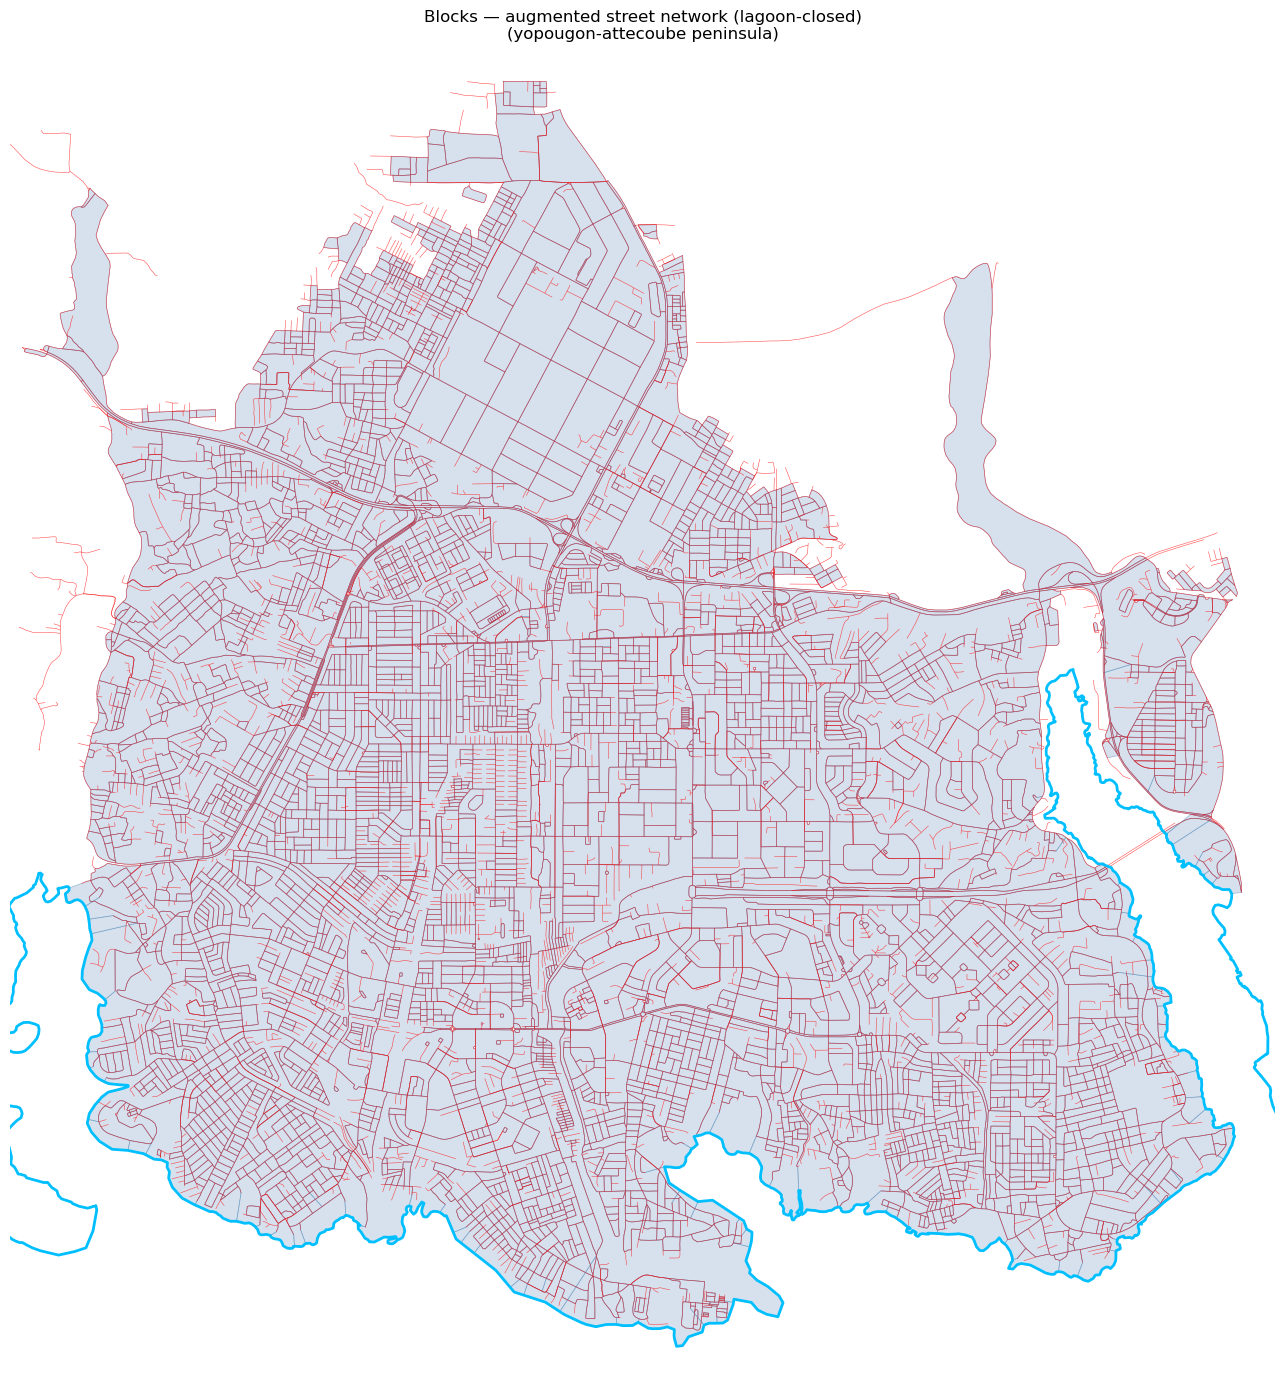

In [6]:
from shapely.ops import polygonize

def _build_blocks(polys, lagoon_geom, orig_union, lagoon_shore, crs):
    """Filter a raw polygon list into a clean blocks GeoDataFrame.

    Removes slivers (area ≤ 500 m²), water polygons (centroid inside lagoon),
    and lagoon-edge artifacts (>20 % overlap with street-only baseline blocks).
    Resets the index and assigns a sequential block_id.
    """
    gdf = geopandas.GeoDataFrame(geometry=polys, crs=crs).reset_index(drop=True)
    gdf = gdf[gdf.area > 500].copy()
    gdf = gdf[~gdf.centroid.within(lagoon_geom)].copy()
    if orig_union is not None:
        _shore_buf = lagoon_shore.buffer(2.0)
        _is_lagoon = gdf.geometry.apply(lambda g: g.intersects(_shore_buf))
        _overlap_frac = gdf.loc[_is_lagoon, "geometry"].apply(
            lambda g: g.intersection(orig_union).area / g.area
        )
        _bad = _overlap_frac[_overlap_frac > 0.20].index
        if len(_bad):
            print(f"Removing {len(_bad)} lagoon block(s) with > 20 % overlap "
                  f"with existing blocks")
            gdf = gdf.drop(_bad)
    gdf = gdf.reset_index(drop=True)
    gdf["block_id"] = gdf.index
    return gdf

# ── Original blocks (streets only) — used later for overlap validation ──────
_orig_polys  = [p for p in polygonize(streets.geometry.unary_union) if p.area > 500]
_orig_union  = unary_union(_orig_polys) if _orig_polys else None
print(f"Original blocks (streets only): {len(_orig_polys):,}")

# ── Rule (b): perpendicular connectors for sections not covered by rule (a) ──
#
# 'Network explosion': for each street, nearest_points(street_geom, lagoon_shore)
# finds the closest point anywhere on the LineString geometry — including
# mid-segment — so L- or S-shaped roads that OSM stores as a single entity
# with two endpoints are handled correctly.

COVERAGE_R  = 100  # m — landing is 'covered' if a rule-a connector lands within this
MIN_SPACE_B = 100  # m — minimum spacing between rule-b landing points

# Vectorised pre-filter: keep only streets within 600 m of the lagoon shore
_streets_near = streets[streets.geometry.distance(lagoon_shore) < 600]
print(f"Street segments within 600 m of lagoon: {len(_streets_near):,}")

# For each nearby street, compute (closest_pt_on_street, landing_pt_on_lagoon, dist)
_candidates = []
for _sg in _streets_near.geometry:
    _src_pt, _land_pt = nearest_points(_sg, lagoon_shore)
    _candidates.append((_src_pt, _land_pt, _src_pt.distance(_land_pt)))

# Sort by connector length — prefer shorter (more perpendicular) connections
_candidates.sort(key=lambda x: x[2])

connectors_b  = []
landing_pts_b = []

for _src_pt, _land_pt, _ in _candidates:
    # Skip if this landing is already covered by rule (a)
    if any(_land_pt.distance(_lp) < COVERAGE_R for _lp in landing_pts_a):
        continue
    # Skip if too close to a previous rule-b landing
    if any(_land_pt.distance(_lp) < MIN_SPACE_B for _lp in landing_pts_b):
        continue

    # Reject connectors nearly parallel to the shore
    _pos  = lagoon_shore.project(_land_pt)
    _eps  = 5.0
    _tb   = lagoon_shore.interpolate(max(0.0, _pos - _eps))
    _ta   = lagoon_shore.interpolate(min(lagoon_shore.length, _pos + _eps))
    _tang = np.array([_ta.x - _tb.x, _ta.y - _tb.y])
    _conn = np.array([_land_pt.x - _src_pt.x, _land_pt.y - _src_pt.y])
    _tn, _cn = np.linalg.norm(_tang), np.linalg.norm(_conn)
    if _tn < 1e-6 or _cn < 1e-6:
        continue
    if abs(_tang[0]*_conn[1] - _tang[1]*_conn[0]) / (_tn * _cn) < 0.5:
        continue  # too parallel to shore — skip

    connectors_b.append(LineString([_src_pt, _land_pt]))
    landing_pts_b.append(_land_pt)

print(f"Rule (b): {len(connectors_b)} perpendicular shore connectors")
print(f"Total new edges: {len(connectors_a) + len(connectors_b)}")

# ── Augmented polygonize ──────────────────────────────────────────────────
_all_lines = list(streets.geometry) + connectors_a + connectors_b + [lagoon_shore]
_aug_union  = unary_union(_all_lines)
block_polys = list(polygonize(_aug_union))

blocks = _build_blocks(block_polys, lagoon_geom, _orig_union, lagoon_shore, streets.crs)
print(f"\nBlocks (lagoon-closed): {len(blocks):,}")
print(f"Block area stats (m²):\n{blocks.area.describe()}")

# ── Crop extent: the main contiguous built-up PENINSULA within Yopougon+Attécoubé ──────────
# (largest connected component of blocks overlapping _ya_geom — excludes the rural hinterland
# the admin boundary also covers, and the small disconnected exclaves further south)
_ya_blocks = blocks[blocks.intersects(_ya_geom)]
_ya_parts  = (geopandas.GeoSeries([_ya_blocks.union_all()], crs=blocks.crs)
              .explode(index_parts=False).reset_index(drop=True))
_peninsula = _ya_parts.loc[_ya_parts.area.idxmax()]
_pen_minx, _pen_miny, _pen_maxx, _pen_maxy = _peninsula.bounds
PEN_XLIM = (_pen_minx - MAP_PAD, _pen_maxx + MAP_PAD)
PEN_YLIM = (_pen_miny - MAP_PAD, _pen_maxy + MAP_PAD)

# Plot — extent limited to the yopougon-attecoube peninsula (see PEN_XLIM/PEN_YLIM above)
fig, ax = plt.subplots(figsize=(14, 14))
blocks.plot(ax=ax, facecolor="lightsteelblue", edgecolor="steelblue",
            linewidth=0.5, alpha=0.5)
streets.plot(ax=ax, color="red", linewidth=0.4, alpha=0.7)
geopandas.GeoDataFrame(
    geometry=[lagoon_shore], crs=streets.crs
).plot(ax=ax, color="deepskyblue", linewidth=2)
ax.set_title("Blocks — augmented street network (lagoon-closed)\n(yopougon-attecoube peninsula)", fontsize=12)
ax.set_xlim(PEN_XLIM)
ax.set_ylim(PEN_YLIM)
ax.set_axis_off()
plt.tight_layout()
plt.show()

Waterways in AOI: 449
{'drain': 298, 'stream': 134, 'river': 15, 'canal': 2}


Removing 30 lagoon block(s) with > 20 % overlap with existing blocks

Blocks (lagoon-closed + waterway-split): 11,647
Block area stats (m²):
count    1.164700e+04
mean     2.380064e+04
std      1.740383e+05
min      5.008308e+02
25%      4.977477e+03
50%      8.892867e+03
75%      1.487460e+04
max      1.246637e+07
dtype: float64


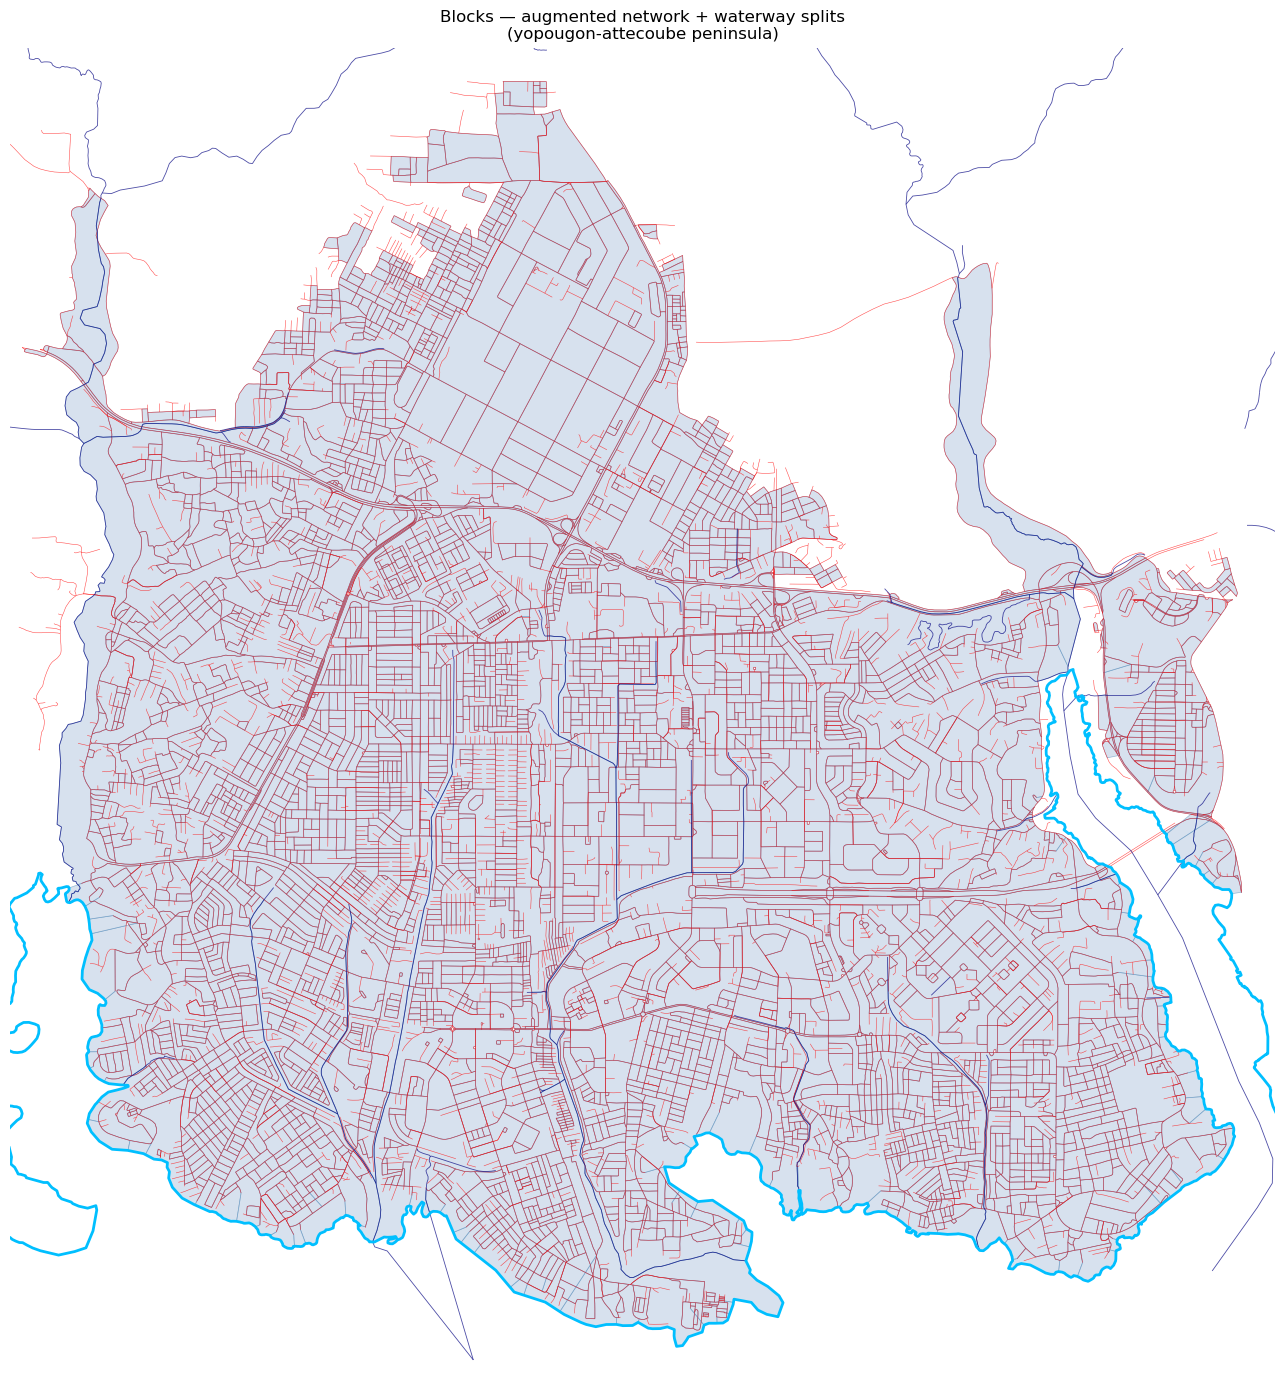

In [7]:
# ── Waterway-split blocks ────────────────────────────────────────────────────
# Load OSM waterways, add them to the augmented line network, and re-polygonize.
# This subdivides any block that a waterway crosses without requiring explicit
# polygon-splitting logic — Shapely's polygonize handles the topology.

_waterways = geopandas.read_file(
    "../_GIS/OSM_2025-04-08.shp/gis_osm_waterways_free_1.shp"
).to_crs(streets.crs)

# Clip waterway geometries to the AOI bounding box
_aoi_geom = shapely_box(_minx - 100, _miny - 100, _maxx + 100, _maxy + 100)
_ww_aoi   = geopandas.clip(_waterways, _aoi_geom)
print(f"Waterways in AOI: {len(_ww_aoi):,}")
print(_ww_aoi['fclass'].value_counts().to_dict())

# Re-polygonize with waterways included in the line network
_all_lines_ww = _all_lines + list(_ww_aoi.geometry)
_aug_union_ww  = unary_union(_all_lines_ww)
block_polys_ww = list(polygonize(_aug_union_ww))

blocks = _build_blocks(block_polys_ww, lagoon_geom, _orig_union, lagoon_shore, streets.crs)
print(f"\nBlocks (lagoon-closed + waterway-split): {len(blocks):,}")
print(f"Block area stats (m²):\n{blocks.area.describe()}")

# ── Crop extent: the main contiguous built-up PENINSULA within Yopougon+Attécoubé ──────────
# (recomputed from this cell's own `blocks`, self-contained — see the first plot for the rationale)
_ya_blocks = blocks[blocks.intersects(_ya_geom)]
_ya_parts  = (geopandas.GeoSeries([_ya_blocks.union_all()], crs=blocks.crs)
              .explode(index_parts=False).reset_index(drop=True))
_peninsula = _ya_parts.loc[_ya_parts.area.idxmax()]
_pen_minx, _pen_miny, _pen_maxx, _pen_maxy = _peninsula.bounds
PEN_XLIM = (_pen_minx - MAP_PAD, _pen_maxx + MAP_PAD)
PEN_YLIM = (_pen_miny - MAP_PAD, _pen_maxy + MAP_PAD)

# Plot — extent limited to the yopougon-attecoube peninsula (see PEN_XLIM/PEN_YLIM above)
fig, ax = plt.subplots(figsize=(14, 14))
blocks.plot(ax=ax, facecolor="lightsteelblue", edgecolor="steelblue",
            linewidth=0.5, alpha=0.5)
streets.plot(ax=ax, color="red", linewidth=0.4, alpha=0.7)
_ww_aoi.plot(ax=ax, color="navy", linewidth=0.6, alpha=0.7)
geopandas.GeoDataFrame(
    geometry=[lagoon_shore], crs=streets.crs
).plot(ax=ax, color="deepskyblue", linewidth=2)
ax.set_title("Blocks — augmented network + waterway splits\n(yopougon-attecoube peninsula)", fontsize=12)
ax.set_xlim(PEN_XLIM)
ax.set_ylim(PEN_YLIM)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [8]:
# Export blocks for the spatial-deprivation-score notebook and for QGIS verification.
# block_id is included — the next notebook joins building statistics to blocks via this key.
# layer= is pinned so re-runs overwrite cleanly rather than accumulating layers.
blocks[["block_id", "geometry"]].to_crs(epsg=export_crs).to_file(
    "data/temp/_check-blocks_geom.gpkg",
    layer="blocks",
    driver="GPKG",
)